# Customer-retention uplift modelling — S / T / X / DR / R learners, Qini + policy value, sleeping-dog detection

**The problem.** A subscription business is considering a retention offer (a 15 % discount, or a month free, or a white-glove account-manager outreach). The treasury team's question is not *who will churn?* but **who will churn *without* the offer and stay *with* it?** — that's *uplift* or *conditional average treatment effect* (CATE), not prediction of churn.

Four customer types matter:

| Segment | Without offer | With offer | CATE | What we should do |
|--------|----------|----------|------|-------------------|
| Persuadable | churns | stays | **negative** | target them |
| Sure thing | stays | stays | zero | skip — offer is free margin loss |
| Lost cause | churns | churns | zero | skip — offer is wasted |
| **Sleeping dog** | stays | **churns** | **positive** | **absolutely do not target** — offer reminds them of alternatives |

A churn-prediction model flags *sure things* who would stay anyway and *lost causes* who will churn regardless; it cannot tell you which customers actually *respond* to the offer. A sleeping-dog customer targeted by a naive churn model is actively *nudged to churn faster* — the exact opposite of the campaign's goal. This is the case for uplift modelling.

**The approach.** Five hand-rolled meta-learners on a synthetic 10,000-customer corpus with *known* heterogeneous CATE across 5 segments (including 15 % sleeping-dogs with +0.08 CATE — i.e. the offer *raises* their churn by 8 pp):

1. **S-learner**: one model $\hat{\mu}(X, T)$; CATE = $\hat{\mu}(X, 1) - \hat{\mu}(X, 0)$. Simple, often regresses toward zero.
2. **T-learner**: two models, one per arm, $\hat{\mu}_0(X)$ and $\hat{\mu}_1(X)$. CATE = $\hat{\mu}_1 - \hat{\mu}_0$. Data-wasteful but unbiased.
3. **X-learner** (Künzel 2019): imputes counterfactual treatment effects per arm and fits a second-stage regressor. Good when arms are imbalanced.
4. **DR-learner** with AIPW pseudo-outcomes + cross-fitting (Kennedy 2020). Doubly-robust against outcome or propensity misspecification.
5. **R-learner** (Nie & Wager 2021): Robinson residualisation — residualise $Y$ on $X$ and $T$ on $X$, then regress residuals. Very efficient under overlap.

Evaluation is done against the *known* true CATE (only possible because the data is synthetic) and with operational metrics — Qini coefficient, AUUC, policy-value-at-k, sleeping-dog recall — that translate directly to ROI.

**Reproducibility.** Fully synthetic, no external data, CPU-only, ~1-2 minutes end-to-end on a laptop.


## 0. Setup and overview

Five modelling layers built in order, each reusing the previous one's utilities:

1. Synthesise 10,000 customers across 5 segments with 9 features + known per-segment CATE.
2. Randomise the treatment and generate potential outcomes under the true CATE.
3. Diagnostics: randomisation check, class balance, segment separability.
4. Five uplift learners, each implemented from first principles in 15-30 lines.
5. CATE quality vs the known truth: Pearson / Kendall correlation, RMSE, segment-level recovery table.
6. Uplift curves + Qini coefficient + AUUC.
7. Policy value at top-k % and cost-aware targeting threshold.
8. Sleeping-dog detection + subgroup heterogeneity recovery.
9. Model card + persistence + inference-parity check.

Libraries: numpy, pandas, scikit-learn, scipy, matplotlib. No `econml` / `causalml` / `lightgbm` imports — every learner is a few dozen lines so the algorithms stay visible.


In [1]:
import json, time, warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from scipy.stats import kendalltau, pearsonr

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 20260424
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ART_DIR = ROOT / "artifacts" / "uplift"
ART_DIR.mkdir(parents=True, exist_ok=True)

print(f"numpy: {np.__version__}   sklearn: {__import__('sklearn').__version__}")
print(f"Artifacts: {ART_DIR.relative_to(ROOT)}")


numpy: 2.4.3   sklearn: 1.6.1
Artifacts: artifacts\uplift


## 1. Synthesise the customer corpus with known heterogeneous CATE

10,000 subscribers drawn from 5 latent segments. Each segment has a **deterministic true CATE** (plus tiny individual noise) and a distinctive feature profile so the learners have a chance of telling them apart:

| Segment | Prior | True CATE on churn | Feature signature |
|--------|-------|--------------------|--------------------|
| Persuadable | 30 % | **-0.15** (offer reduces churn by 15pp) | Medium tenure, moderate spend, occasional support, active login |
| Lost cause | 20 % | 0.00 (already churning) | Low tenure, low spend, many support tickets, dormant login |
| Sure thing | 20 % | 0.00 (will stay regardless) | Short tenure, modest spend, no support, low engagement |
| **Sleeping dog** | 15 % | **+0.08** (offer backfires) | Long tenure, high spend, zero support, 97 % auto-renew — "high-value loyal whales" |
| Mixed | 15 % | -0.03 (small positive) | Middle of everything |

Features (9 total): `tenure`, `monthly_rev`, `support_n`, `days_last_login`, `product_count`, `age_band`, `auto_renew`, `prior_offers_accepted`, `engagement_score`.

Treatment is randomised 50 / 50 — a true experiment. The observed outcome is $Y = Y(0)$ in control and $Y(0) + \mathrm{CATE}$ in treatment (binary churn in [0, 1]).

Since the corpus is synthetic we know the **ground-truth CATE per customer**. All later sections validate against it.


In [2]:
N = 10_000
rng = np.random.default_rng(SEED)

SEG_SPEC = [
    ("persuadable",  0.30, -0.15),   # offer reduces churn by 15pp
    ("lost_cause",   0.20,  0.00),   # already churning
    ("sure_thing",   0.20,  0.00),   # will stay regardless
    ("sleeping_dog", 0.15, +0.08),   # offer BACKFIRES
    ("mixed",        0.15, -0.03),   # small positive effect
]
segment_names = [s[0] for s in SEG_SPEC]
segment_probs = np.array([s[1] for s in SEG_SPEC])
segment_cate = {s[0]: s[2] for s in SEG_SPEC}

seg_idx = rng.choice(len(SEG_SPEC), size=N, p=segment_probs / segment_probs.sum())
segment = np.array([segment_names[i] for i in seg_idx])

# Per-segment feature means
tenure_mean          = np.array([ 28,     6,    12,    48,     18])
rev_mean             = np.array([ 65,    30,    40,   100,     50])
support_mean         = np.array([  1,     6,     1,     0,      2])
last_login_mean      = np.array([  3,    25,     5,     1,      7])
product_mean         = np.array([  3,     1,     2,     5,      2])
auto_renew_prob      = np.array([0.80,  0.30,  0.60,  0.97,   0.55])
prior_offers_mean    = np.array([  2,     0,     0,     0,      1])
engagement_mean      = np.array([0.65,  0.20,  0.45,  0.90,   0.50])
# Baseline churn (control outcome) per segment
baseline_churn       = np.array([0.25,  0.70,  0.05,  0.15,   0.18])

tenure          = np.clip(rng.normal(tenure_mean[seg_idx], 6), 0, 80)
monthly_rev     = np.clip(rng.normal(rev_mean[seg_idx], 15), 5, 250)
support_n       = rng.poisson(support_mean[seg_idx])
days_last_login = np.clip(rng.normal(last_login_mean[seg_idx], 4), 0, 60)
product_count   = np.clip(rng.poisson(product_mean[seg_idx]), 0, 10)
age_band        = rng.integers(0, 5, size=N)
auto_renew      = (rng.random(N) < auto_renew_prob[seg_idx]).astype(int)
prior_offers    = rng.poisson(prior_offers_mean[seg_idx])
engagement      = np.clip(rng.normal(engagement_mean[seg_idx], 0.1), 0, 1)

X = pd.DataFrame({
    "tenure":        tenure,
    "monthly_rev":   monthly_rev,
    "support_n":     support_n,
    "days_last_login": days_last_login,
    "product_count": product_count,
    "age_band":      age_band,
    "auto_renew":    auto_renew,
    "prior_offers_accepted": prior_offers,
    "engagement_score": engagement,
})

# --- Randomised treatment (true A/B test) ---
T = (rng.random(N) < 0.5).astype(int)

# --- True CATE and potential outcomes ---
true_cate = np.array([segment_cate[s] for s in segment]) + rng.normal(0, 0.01, N)
Y0_prob = np.clip(baseline_churn[seg_idx] + rng.normal(0, 0.03, N), 0, 1)
Y1_prob = np.clip(Y0_prob + true_cate, 0, 1)
Y_prob  = np.where(T == 1, Y1_prob, Y0_prob)
Y = (rng.random(N) < Y_prob).astype(int)

# Cross-validated arrays
Xarr = X.to_numpy().astype(np.float32)

print(f"N = {N:,}   features = {X.shape[1]}")
print(f"Overall churn: {Y.mean():.3f}   (control: {Y[T==0].mean():.3f}   treatment: {Y[T==1].mean():.3f})")
print(f"True ATE (population-average CATE): {true_cate.mean():+.4f}")
print(f"Naive ATE (diff of means):          {Y[T==1].mean() - Y[T==0].mean():+.4f}")


N = 10,000   features = 9
Overall churn: 0.258   (control: 0.274   treatment: 0.242)
True ATE (population-average CATE): -0.0375
Naive ATE (diff of means):          -0.0322


## 2. Randomisation check and segment profile

Three quick diagnostics before any modelling:

1. **Balance across features** — a proper randomisation produces equal feature means in treatment and control. Any systematic gap is a red flag.
2. **Segment profile** — show the feature signatures that *should* let a strong learner separate the segments.
3. **Observed churn by segment × treatment** — verifies that the CATE structure we injected is visible in the observed outcomes (sleeping-dogs should churn MORE in treatment; persuadables much LESS).


In [3]:
# Balance check
balance = pd.DataFrame({
    "feature": X.columns,
    "ctrl_mean": X[T == 0].mean().values.round(2),
    "trt_mean":  X[T == 1].mean().values.round(2),
})
balance["abs_std_diff"] = ((balance["trt_mean"] - balance["ctrl_mean"]).abs()
                            / (X.std().values + 1e-8)).round(3)
print("Randomisation balance (abs standardised diff < 0.1 = good):")
print(balance.to_string(index=False))

# Segment profile
seg_profile = X.copy(); seg_profile["segment"] = segment
print("\nMean features by segment:")
print(seg_profile.groupby("segment").mean().round(2).to_string())

# Observed churn by segment x treatment
print("\nObserved churn rate by segment x treatment (validates the injected CATE):")
churn_tbl = pd.DataFrame({"segment": segment, "T": T, "Y": Y}).groupby(["segment", "T"])["Y"].mean().unstack()
churn_tbl.columns = ["control", "treatment"]
churn_tbl["observed_CATE"] = (churn_tbl["treatment"] - churn_tbl["control"]).round(3)
churn_tbl["true_CATE"] = [segment_cate[s] for s in churn_tbl.index]
print(churn_tbl.round(3).to_string())


Randomisation balance (abs standardised diff < 0.1 = good):
              feature  ctrl_mean  trt_mean  abs_std_diff
               tenure      22.24     22.11         0.009
          monthly_rev      56.58     56.35         0.009
            support_n       1.97      1.98         0.004
      days_last_login       8.36      8.54         0.020
        product_count       2.55      2.56         0.005
             age_band       2.02      1.98         0.029
           auto_renew       0.65      0.65         0.000
prior_offers_accepted       0.78      0.74         0.032
     engagement_score       0.54      0.53         0.042

Mean features by segment:
              tenure  monthly_rev  support_n  days_last_login  product_count  age_band  auto_renew  prior_offers_accepted  engagement_score
segment                                                                                                                                    
lost_cause      6.64        30.49       5.99            24.82  

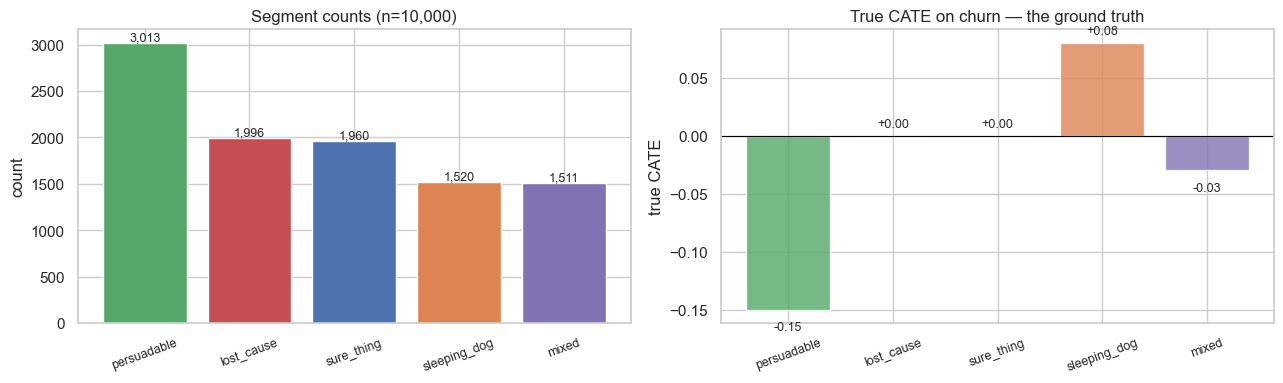

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))

# Segment proportions
seg_counts = pd.Series(segment).value_counts().reindex(segment_names)
colors = ["#55A868", "#C44E52", "#4C72B0", "#DD8452", "#8172B3"]
axes[0].bar(seg_counts.index, seg_counts.values, color=colors)
axes[0].set_ylabel("count"); axes[0].set_title("Segment counts (n=10,000)")
axes[0].tick_params(axis="x", rotation=20, labelsize=9)
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

# True CATE by segment
axes[1].bar(segment_names, [segment_cate[s] for s in segment_names], color=colors, alpha=0.8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("true CATE"); axes[1].set_title("True CATE on churn — the ground truth")
axes[1].tick_params(axis="x", rotation=20, labelsize=9)
for i, s in enumerate(segment_names):
    v = segment_cate[s]
    axes[1].text(i, v + (0.005 if v >= 0 else -0.01), f"{v:+.2f}",
                  ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
plt.tight_layout(); plt.show()


## 3. ATE baselines — where we start

Before any uplift model, two classical ATE estimators:

- **Difference-in-means** (valid under randomisation): $\hat{\tau} = \bar{Y}_1 - \bar{Y}_0$.
- **OLS-adjusted**: regress $Y$ on $T$ + $X$; the coefficient on $T$ is the covariate-adjusted ATE, with tighter confidence interval than diff-of-means.

Both estimators return a single number — the *average* treatment effect. They cannot tell you *which* customers are persuadables vs sleeping-dogs. That's the step we need uplift modelling for.


In [5]:
# Difference-of-means ATE with classical standard error
ate_dim = Y[T == 1].mean() - Y[T == 0].mean()
se_dim = np.sqrt(Y[T == 1].var(ddof=1) / (T == 1).sum()
                  + Y[T == 0].var(ddof=1) / (T == 0).sum())
ci_dim = (ate_dim - 1.96 * se_dim, ate_dim + 1.96 * se_dim)

# OLS-adjusted ATE (sklearn fit on design matrix)
from sklearn.linear_model import LinearRegression
design = np.hstack([Xarr, T.reshape(-1, 1)])
ols = LinearRegression().fit(design, Y)
ate_ols = ols.coef_[-1]

# Bootstrap CI on OLS-adjusted ATE
B = 500
boots = np.empty(B)
rng_boot = np.random.default_rng(SEED + 1)
for b in range(B):
    idx = rng_boot.integers(0, N, size=N)
    m = LinearRegression().fit(design[idx], Y[idx])
    boots[b] = m.coef_[-1]
ci_ols = (float(np.quantile(boots, 0.025)), float(np.quantile(boots, 0.975)))

ate_rows = pd.DataFrame([
    {"estimator": "truth (population CATE avg)", "ATE": round(true_cate.mean(), 4),
     "CI_low": "-", "CI_high": "-"},
    {"estimator": "diff-of-means", "ATE": round(ate_dim, 4),
     "CI_low": round(ci_dim[0], 4), "CI_high": round(ci_dim[1], 4)},
    {"estimator": "OLS-adjusted", "ATE": round(ate_ols, 4),
     "CI_low": round(ci_ols[0], 4), "CI_high": round(ci_ols[1], 4)},
])
print("ATE estimators (churn reduction; negative = offer reduces churn):")
print(ate_rows.to_string(index=False))


ATE estimators (churn reduction; negative = offer reduces churn):
                  estimator     ATE  CI_low CI_high
truth (population CATE avg) -0.0375       -       -
              diff-of-means -0.0322 -0.0494 -0.0151
               OLS-adjusted -0.0356 -0.0502 -0.0204


## 4. S-learner

The simplest meta-learner: **one** supervised model predicting $Y$ from $(X, T)$. The CATE for a customer is the difference $\hat{\mu}(X, 1) - \hat{\mu}(X, 0)$ — i.e., plug in $T=1$, plug in $T=0$, subtract.

- **Pros**: data-efficient (all rows used in one fit), simple to ship.
- **Cons**: if the base learner doesn't find strong $T \times X$ interactions, predicted CATE collapses toward zero (the model learns the *average* treatment effect and fails to separate subgroups). The base model should therefore be a tree-ensemble or equivalent non-linear learner that can naturally find interactions.

Base model: `HistGradientBoostingClassifier(max_iter=120, max_depth=5)`. Training cost: ~1 s on 10k × 10 features.


In [6]:
def fit_s_learner(X, T, Y):
    model = HistGradientBoostingClassifier(max_iter=120, max_depth=5, random_state=0)
    XT = np.hstack([X, T.reshape(-1, 1)])
    model.fit(XT, Y)
    X1 = np.hstack([X, np.ones((len(X), 1))])
    X0 = np.hstack([X, np.zeros((len(X), 1))])
    return model.predict_proba(X1)[:, 1] - model.predict_proba(X0)[:, 1], model


t0 = time.monotonic()
cate_s, s_model = fit_s_learner(Xarr, T, Y)
print(f"S-learner fit in {time.monotonic() - t0:.2f}s")
print(f"  predicted ATE = {cate_s.mean():+.4f}   (truth = {true_cate.mean():+.4f})")
print(f"  Pearson r vs truth  = {pearsonr(cate_s, true_cate)[0]:+.3f}")
print(f"  Kendall tau vs truth = {kendalltau(cate_s, true_cate)[0]:+.3f}")
print(f"  RMSE vs truth        = {np.sqrt(np.mean((cate_s - true_cate) ** 2)):.4f}")


S-learner fit in 1.61s
  predicted ATE = -0.0343   (truth = -0.0375)
  Pearson r vs truth  = +0.770
  Kendall tau vs truth = +0.578
  RMSE vs truth        = 0.0519


## 5. T-learner

Two separate models, one per treatment arm: $\hat{\mu}_0$ on control only, $\hat{\mu}_1$ on treatment only. CATE = $\hat{\mu}_1(X) - \hat{\mu}_0(X)$.

- **Pros**: no shared-representation bias; each arm's model can specialise.
- **Cons**: **data-wasteful** — each arm sees only half the rows. If treatment effects are small relative to baseline variation, the difference-of-two-noisy-fits is dominated by noise. Very unbalanced arms (e.g. 5 % treatment) make this worse.


In [7]:
def fit_t_learner(X, T, Y):
    m0 = HistGradientBoostingClassifier(max_iter=120, max_depth=5, random_state=0).fit(X[T == 0], Y[T == 0])
    m1 = HistGradientBoostingClassifier(max_iter=120, max_depth=5, random_state=1).fit(X[T == 1], Y[T == 1])
    return m1.predict_proba(X)[:, 1] - m0.predict_proba(X)[:, 1], (m0, m1)


t0 = time.monotonic()
cate_t, t_models = fit_t_learner(Xarr, T, Y)
print(f"T-learner fit in {time.monotonic() - t0:.2f}s")
print(f"  predicted ATE = {cate_t.mean():+.4f}")
print(f"  Pearson r     = {pearsonr(cate_t, true_cate)[0]:+.3f}")
print(f"  Kendall tau   = {kendalltau(cate_t, true_cate)[0]:+.3f}")
print(f"  RMSE          = {np.sqrt(np.mean((cate_t - true_cate) ** 2)):.4f}")


T-learner fit in 0.32s
  predicted ATE = -0.0368
  Pearson r     = +0.468
  Kendall tau   = +0.342
  RMSE          = 0.1259


## 6. X-learner

Künzel et al. 2019's X-learner combines T-learner's strengths with imputed treatment effects. Two stages:

1. **Stage 1**: fit $\hat{\mu}_0$ on control and $\hat{\mu}_1$ on treatment (same as T-learner).
2. **Stage 2**: for each *treated* customer compute $D_i = Y_i - \hat{\mu}_0(X_i)$ (their imputed treatment effect); for each *control* compute $D_i = \hat{\mu}_1(X_i) - Y_i$. Regress the imputed $D_i$ on $X_i$ separately for each arm to get $\hat{\tau}_0$ and $\hat{\tau}_1$. Final CATE = $e(X) \hat{\tau}_0(X) + (1 - e(X)) \hat{\tau}_1(X)$ where $e$ is the propensity.

Practical gain: the Stage-2 regressors are trained on *imputed* effects (often smoother signals than raw outcomes), so the X-learner is **more sample-efficient than T on imbalanced arms**.


In [8]:
def fit_x_learner(X, T, Y):
    m0 = HistGradientBoostingClassifier(max_iter=120, max_depth=5, random_state=0).fit(X[T == 0], Y[T == 0])
    m1 = HistGradientBoostingClassifier(max_iter=120, max_depth=5, random_state=1).fit(X[T == 1], Y[T == 1])
    # Imputed treatment effects
    D1 = Y[T == 1] - m0.predict_proba(X[T == 1])[:, 1]
    D0 = m1.predict_proba(X[T == 0])[:, 1] - Y[T == 0]
    tau1 = HistGradientBoostingRegressor(max_iter=120, max_depth=4, random_state=2).fit(X[T == 1], D1)
    tau0 = HistGradientBoostingRegressor(max_iter=120, max_depth=4, random_state=3).fit(X[T == 0], D0)
    # Propensity (randomised here, but we learn it anyway)
    prop = LogisticRegression(max_iter=400).fit(X, T)
    e = np.clip(prop.predict_proba(X)[:, 1], 0.05, 0.95)
    return e * tau0.predict(X) + (1 - e) * tau1.predict(X), (m0, m1, tau0, tau1, prop)


t0 = time.monotonic()
cate_x, x_models = fit_x_learner(Xarr, T, Y)
print(f"X-learner fit in {time.monotonic() - t0:.2f}s")
print(f"  predicted ATE = {cate_x.mean():+.4f}")
print(f"  Pearson r     = {pearsonr(cate_x, true_cate)[0]:+.3f}")
print(f"  Kendall tau   = {kendalltau(cate_x, true_cate)[0]:+.3f}")
print(f"  RMSE          = {np.sqrt(np.mean((cate_x - true_cate) ** 2)):.4f}")


X-learner fit in 0.62s
  predicted ATE = -0.0369
  Pearson r     = +0.629
  Kendall tau   = +0.448
  RMSE          = 0.0820


## 7. DR-learner with AIPW pseudo-outcomes + cross-fitting

The doubly-robust approach (Kennedy 2020). Construct a per-customer **AIPW pseudo-outcome**:

$$\psi_i = \hat{\mu}_1(X_i) - \hat{\mu}_0(X_i) + \frac{T_i \, (Y_i - \hat{\mu}_1(X_i))}{\hat{e}(X_i)} - \frac{(1 - T_i)\,(Y_i - \hat{\mu}_0(X_i))}{1 - \hat{e}(X_i)}$$

Two crucial properties:

1. **Doubly robust**: $E[\psi \mid X]$ equals the true CATE if *either* the outcome models $\hat{\mu}_{0,1}$ *or* the propensity $\hat{e}$ are correctly specified — a big practical win in observational data.
2. **Cross-fitting** (Chernozhukov et al. 2018): nuisance models $\hat{\mu}_{0,1}$ and $\hat{e}$ are fit on one fold and applied to the held-out fold. Removes overfitting bias that would otherwise invalidate the doubly-robust guarantee.

After building $\psi$ we fit a regressor $\hat{\tau}(X)$ to predict $\psi$ — the standard "regress the pseudo-outcome on $X$" move.

Training cost: 5-fold cross-fitting triples the total fit time (3 models × 5 folds) but keeps it well under 10 s.


In [9]:
def fit_dr_learner(X, T, Y, n_splits: int = 5, seed: int = 0):
    psi = np.zeros(len(X))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for train_idx, test_idx in kf.split(X):
        # Propensity model on train fold
        prop = LogisticRegression(max_iter=400).fit(X[train_idx], T[train_idx])
        e = np.clip(prop.predict_proba(X[test_idx])[:, 1], 0.05, 0.95)
        # Arm-specific outcome models on train fold
        m0 = HistGradientBoostingClassifier(max_iter=120, max_depth=5,
                                              random_state=2).fit(
            X[train_idx][T[train_idx] == 0], Y[train_idx][T[train_idx] == 0])
        m1 = HistGradientBoostingClassifier(max_iter=120, max_depth=5,
                                              random_state=3).fit(
            X[train_idx][T[train_idx] == 1], Y[train_idx][T[train_idx] == 1])
        mu0 = m0.predict_proba(X[test_idx])[:, 1]
        mu1 = m1.predict_proba(X[test_idx])[:, 1]
        # AIPW pseudo-outcome on held-out fold
        Tt = T[test_idx]; Yt = Y[test_idx]
        psi[test_idx] = (mu1 - mu0
                         + Tt * (Yt - mu1) / e
                         - (1 - Tt) * (Yt - mu0) / (1 - e))
    # Second-stage: regress psi on X
    tau = HistGradientBoostingRegressor(max_iter=200, max_depth=4, random_state=0).fit(X, psi)
    return tau.predict(X), (tau, psi)


t0 = time.monotonic()
cate_dr, dr_models = fit_dr_learner(Xarr, T, Y)
print(f"DR-learner fit in {time.monotonic() - t0:.2f}s (5-fold cross-fitting)")
print(f"  predicted ATE = {cate_dr.mean():+.4f}")
print(f"  Pearson r     = {pearsonr(cate_dr, true_cate)[0]:+.3f}")
print(f"  Kendall tau   = {kendalltau(cate_dr, true_cate)[0]:+.3f}")
print(f"  RMSE          = {np.sqrt(np.mean((cate_dr - true_cate) ** 2)):.4f}")


DR-learner fit in 2.09s (5-fold cross-fitting)
  predicted ATE = -0.0359
  Pearson r     = +0.441
  Kendall tau   = +0.311
  RMSE          = 0.1396


## 8. R-learner (Robinson residualisation)

Nie & Wager 2021's R-learner uses the Robinson (1988) decomposition. Define outcome and propensity residuals

$$\tilde{Y}_i = Y_i - \hat{m}(X_i), \qquad \tilde{T}_i = T_i - \hat{e}(X_i)$$

and fit $\hat{\tau}(X)$ by weighted regression of $\tilde{Y}/\tilde{T}$ on $X$ with weights $\tilde{T}^2$. This is a specific instance of the **double / debiased ML framework** that cancels first-order bias from the nuisance estimators.

R-learner tends to be very sample-efficient under overlap (true here — treatment is a coin flip) and handles high-dimensional nuisance extremely well. It is the estimator of choice in modern causal-ML pipelines.


In [10]:
def fit_r_learner(X, T, Y, n_splits: int = 5, seed: int = 1):
    e_hat = np.zeros(len(X))
    m_hat = np.zeros(len(X))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for train_idx, test_idx in kf.split(X):
        prop = LogisticRegression(max_iter=400).fit(X[train_idx], T[train_idx])
        e_hat[test_idx] = np.clip(prop.predict_proba(X[test_idx])[:, 1], 0.05, 0.95)
        out = HistGradientBoostingClassifier(max_iter=120, max_depth=5,
                                               random_state=0).fit(X[train_idx], Y[train_idx])
        m_hat[test_idx] = out.predict_proba(X[test_idx])[:, 1]
    Y_res = Y - m_hat
    T_res = T - e_hat
    # Target (Y_res / T_res) with weights T_res^2 realises the R-loss in closed form.
    target = Y_res / T_res
    weights = T_res ** 2
    tau = HistGradientBoostingRegressor(max_iter=300, max_depth=5, learning_rate=0.05,
                                          random_state=0).fit(X, target, sample_weight=weights)
    return tau.predict(X), (tau, e_hat, m_hat)


t0 = time.monotonic()
cate_r, r_models = fit_r_learner(Xarr, T, Y)
print(f"R-learner fit in {time.monotonic() - t0:.2f}s")
print(f"  predicted ATE = {cate_r.mean():+.4f}")
print(f"  Pearson r     = {pearsonr(cate_r, true_cate)[0]:+.3f}")
print(f"  Kendall tau   = {kendalltau(cate_r, true_cate)[0]:+.3f}")
print(f"  RMSE          = {np.sqrt(np.mean((cate_r - true_cate) ** 2)):.4f}")


R-learner fit in 1.56s
  predicted ATE = -0.0372
  Pearson r     = +0.402
  Kendall tau   = +0.288
  RMSE          = 0.1520


## 9. CATE quality comparison

Five learners side-by-side against the known truth. Four metrics:

- **Pearson r** — linear correlation between predicted and true CATE; measures whether ranking matches.
- **Kendall τ** — rank correlation; less sensitive to outliers.
- **RMSE vs truth** — raw magnitude error.
- **Segment-level mean CATE** — per-segment recovery; the key production-readiness test (does the model find persuadables, sleeping-dogs, and neutrals correctly?).

*Beware the rank-vs-magnitude trade-off.* A learner that regresses toward zero can have excellent correlation yet terrible magnitude (miscalibrated). A targeting policy cares about ranking — at the threshold, what matters is who's above. But ROI calculations need calibrated magnitudes.


In [11]:
models_named = {
    "S-learner":  cate_s,
    "T-learner":  cate_t,
    "X-learner":  cate_x,
    "DR-learner": cate_dr,
    "R-learner":  cate_r,
}

rows = []
for name, pred in models_named.items():
    rows.append({
        "model":      name,
        "pred_ATE":   round(float(pred.mean()), 4),
        "RMSE":       round(float(np.sqrt(np.mean((pred - true_cate) ** 2))), 4),
        "Pearson_r":  round(float(pearsonr(pred, true_cate)[0]), 3),
        "Kendall_tau": round(float(kendalltau(pred, true_cate)[0]), 3),
    })
quality_df = pd.DataFrame(rows)
print(f"True ATE: {true_cate.mean():+.4f}")
print("\nCATE quality vs known truth:")
print(quality_df.to_string(index=False))

# Segment-level recovery
seg_rows = []
for s in segment_names:
    mask = segment == s
    row = {"segment": s, "n": int(mask.sum()), "true_CATE": round(segment_cate[s], 3)}
    for name, pred in models_named.items():
        row[name] = round(float(pred[mask].mean()), 3)
    seg_rows.append(row)
seg_recovery_df = pd.DataFrame(seg_rows)
print("\nSegment-level mean predicted CATE by learner (true = column 'true_CATE'):")
print(seg_recovery_df.to_string(index=False))


True ATE: -0.0375

CATE quality vs known truth:
     model  pred_ATE   RMSE  Pearson_r  Kendall_tau
 S-learner   -0.0343 0.0519      0.770        0.578
 T-learner   -0.0368 0.1259      0.468        0.342
 X-learner   -0.0369 0.0820      0.629        0.448
DR-learner   -0.0359 0.1396      0.441        0.311
 R-learner   -0.0372 0.1520      0.402        0.288

Segment-level mean predicted CATE by learner (true = column 'true_CATE'):
     segment    n  true_CATE  S-learner  T-learner  X-learner  DR-learner  R-learner
 persuadable 3013      -0.15     -0.102     -0.128     -0.126      -0.130     -0.129
  lost_cause 1996       0.00      0.007      0.009      0.009       0.012      0.010
  sure_thing 1960       0.00     -0.017     -0.015     -0.015      -0.013     -0.015
sleeping_dog 1520       0.08      0.039      0.064      0.062       0.066      0.062
       mixed 1511      -0.03     -0.051     -0.046     -0.047      -0.042     -0.046


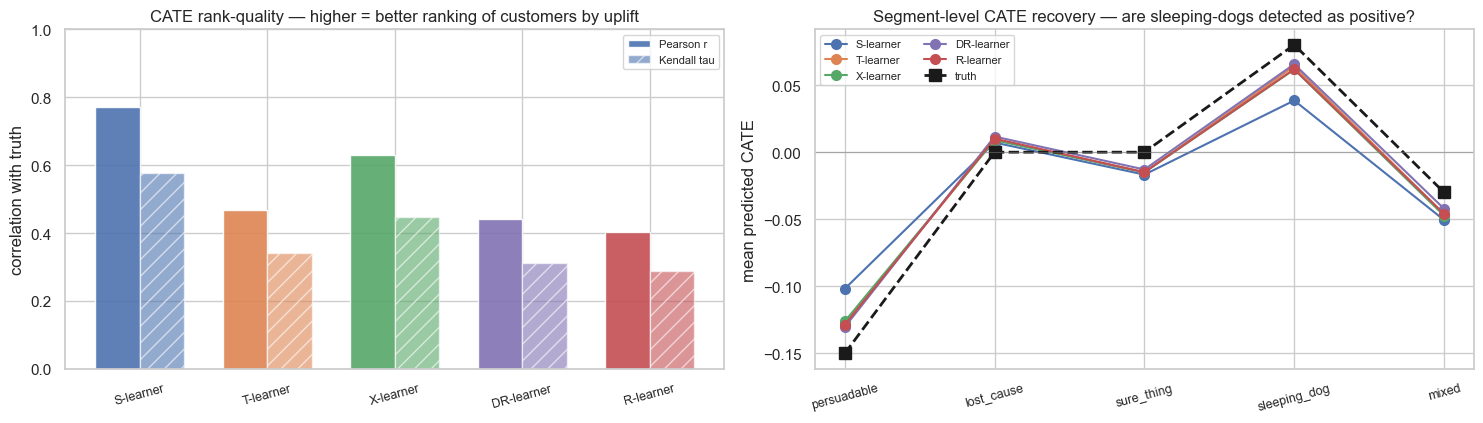

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
palette_m = {"S-learner": "#4C72B0", "T-learner": "#DD8452",
             "X-learner": "#55A868", "DR-learner": "#8172B3", "R-learner": "#C44E52"}

# Panel 1: correlation bars
ax = axes[0]
x_pos = np.arange(len(models_named))
width = 0.35
ax.bar(x_pos - width/2, quality_df["Pearson_r"], width, color=[palette_m[m] for m in quality_df["model"]],
        alpha=0.9, label="Pearson r")
ax.bar(x_pos + width/2, quality_df["Kendall_tau"], width,
        color=[palette_m[m] for m in quality_df["model"]], alpha=0.6, hatch="//", label="Kendall tau")
ax.set_xticks(x_pos); ax.set_xticklabels(quality_df["model"], rotation=15, fontsize=9)
ax.set_ylim(0, 1.0); ax.set_ylabel("correlation with truth")
ax.set_title("CATE rank-quality — higher = better ranking of customers by uplift")
ax.legend(fontsize=8, loc="upper right")

# Panel 2: segment recovery
ax = axes[1]
x_pos = np.arange(len(segment_names))
for i, (name, pred) in enumerate(models_named.items()):
    vals = [pred[segment == s].mean() for s in segment_names]
    ax.plot(x_pos, vals, "o-", color=palette_m[name], label=name, linewidth=1.5, markersize=7)
# Truth
truth_vals = [segment_cate[s] for s in segment_names]
ax.plot(x_pos, truth_vals, "k--s", label="truth", linewidth=2, markersize=9)
ax.axhline(0, color="gray", lw=0.8, alpha=0.5)
ax.set_xticks(x_pos); ax.set_xticklabels(segment_names, rotation=15, fontsize=9)
ax.set_ylabel("mean predicted CATE")
ax.set_title("Segment-level CATE recovery — are sleeping-dogs detected as positive?")
ax.legend(fontsize=8, loc="best", ncol=2)
plt.tight_layout(); plt.show()


## 10. Uplift curves and Qini coefficient

Ranking customers by predicted uplift and computing **cumulative incremental uplift** at each decile builds an **uplift curve**. The area between the curve and the random targeting baseline is the **Qini coefficient** — the headline operational metric for uplift models.

- **Qini > 0**: targeting by model > random targeting.
- **Qini = 0**: model is no better than random.
- **Qini < 0**: model is worse than random — check for bugs.

AUUC (Area Under Uplift Curve) is closely related — some authors use Qini (cumulative incremental uplift normalised) and others use AUUC (unnormalised cumulative gain); we report both for consistency.

Key point: since we *reduce* churn, uplift is the *decrease* in churn from targeting. In all formulas below "uplift" = $-\mathrm{CATE}$ so that larger values = more retention gained. Customers are sorted from largest retention gain to smallest.


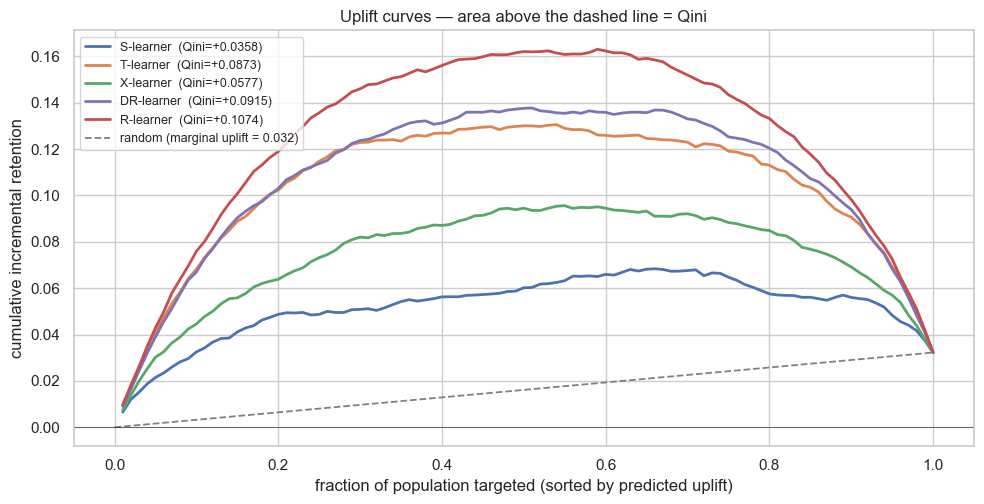

Qini + AUUC by learner:
     model   Qini   AUUC
 S-learner 0.0358 0.0519
 T-learner 0.0873 0.1035
 X-learner 0.0577 0.0738
DR-learner 0.0915 0.1076
 R-learner 0.1074 0.1236


In [13]:
def uplift_curve(pred_cate: np.ndarray, T: np.ndarray, Y: np.ndarray, n_points: int = 100):
    """Cumulative incremental retention gain by targeting top-fraction of customers sorted by predicted uplift.

    We work in retention units: retention = 1 - Y. Uplift = retention_treated - retention_control.
    Sort descending by predicted *retention uplift* (= -pred_cate on churn).
    """
    uplift_score = -pred_cate                 # positive = offer reduces churn
    order = np.argsort(-uplift_score)          # descending
    T_s, Y_s = T[order], Y[order]
    # Retention = 1 - Y
    R_s = 1 - Y_s
    n = len(T_s)
    frac = np.linspace(0.01, 1.0, n_points)
    x_vals = []; uplift = []
    for f in frac:
        k = int(f * n)
        if k == 0:
            uplift.append(0.0); x_vals.append(0.0); continue
        top = slice(0, k)
        n_t = max(int(T_s[top].sum()), 1)
        n_c = max(int((1 - T_s[top]).sum()), 1)
        # Scaled cumulative incremental retention (Qini-style)
        inc = (R_s[top][T_s[top] == 1].sum() / n_t
                - R_s[top][T_s[top] == 0].sum() / n_c)
        uplift.append(inc * k / n)
        x_vals.append(k / n)
    return np.array(x_vals), np.array(uplift)


def qini_coefficient(x_vals: np.ndarray, uplift_vals: np.ndarray, baseline_uplift: float) -> float:
    """Area between uplift curve and the random-baseline line (linear from 0 to baseline)."""
    baseline = x_vals * baseline_uplift
    area = np.trapezoid(uplift_vals - baseline, x_vals)
    return float(area)


# True ATE (reference for the random baseline)
baseline = 1 - Y.mean()               # reference retention
naive_uplift = -(Y[T == 1].mean() - Y[T == 0].mean())   # marginal retention gain from offer

qini_rows = []
fig, ax = plt.subplots(figsize=(10, 5.2))
for name, pred in models_named.items():
    x_vals, uplift_vals = uplift_curve(pred, T, Y)
    qini = qini_coefficient(x_vals, uplift_vals, baseline_uplift=naive_uplift)
    ax.plot(x_vals, uplift_vals, label=f"{name}  (Qini={qini:+.4f})",
            color=palette_m[name], linewidth=2)
    qini_rows.append({"model": name, "Qini": qini,
                       "AUUC": float(np.trapezoid(uplift_vals, x_vals))})
# Random baseline: linear from (0,0) to (1, naive_uplift)
ax.plot([0, 1], [0, naive_uplift], "--", color="gray", lw=1.3, label=f"random (marginal uplift = {naive_uplift:.3f})")
ax.axhline(0, color="black", lw=0.7, alpha=0.5)
ax.set_xlabel("fraction of population targeted (sorted by predicted uplift)")
ax.set_ylabel("cumulative incremental retention")
ax.set_title("Uplift curves — area above the dashed line = Qini")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

qini_df = pd.DataFrame(qini_rows).round(4)
print("Qini + AUUC by learner:")
print(qini_df.to_string(index=False))


## 11. Policy value — what happens if we target top-k %?

The Qini coefficient aggregates across all targeting fractions. In practice you'll only target the top-k % whose predicted uplift exceeds the offer's break-even. We compute **policy value** — realised retention gain if we target the top-k % of customers by predicted uplift — for each learner at a grid of k.

Because our treatment was randomised, the policy value at top-k % is an unbiased estimate of what we would realise rolling out the same targeting strategy to the full customer base.


Policy value (retention gain per targeted customer) at top-k %:
     model   k=5%  k=10%  k=20%  k=30%  k=40%  k=50%  k=75%  k=100%
 S-learner 0.4292 0.3232 0.2435 0.1695 0.1406 0.1203 0.0863  0.0322
 T-learner 0.8185 0.6821 0.5114 0.4094 0.3173 0.2600 0.1588  0.0322
 X-learner 0.6042 0.4457 0.3190 0.2733 0.2176 0.1890 0.1177  0.0322
DR-learner 0.7785 0.6683 0.5149 0.4124 0.3280 0.2751 0.1670  0.0322
 R-learner 0.8588 0.7576 0.5944 0.4865 0.3900 0.3241 0.1912  0.0322


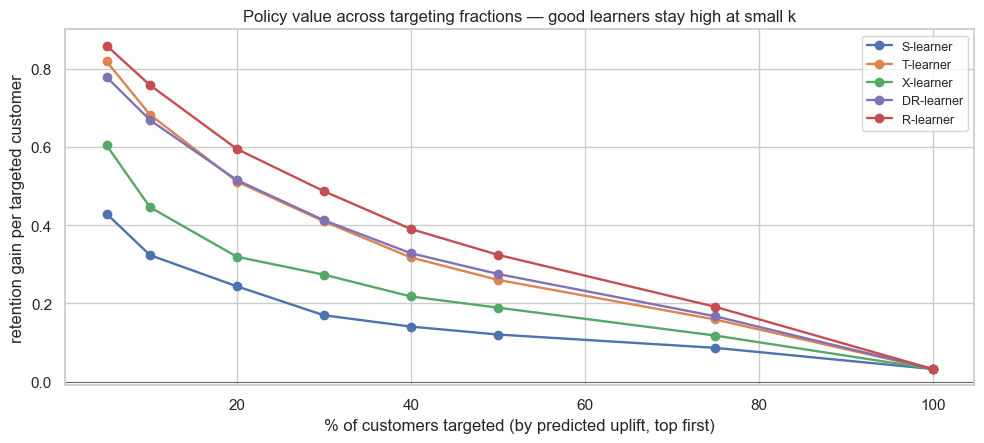

In [14]:
def policy_value(pred_cate: np.ndarray, T: np.ndarray, Y: np.ndarray, k_frac: float) -> float:
    """Expected retention gain per customer if we target the top-k % by predicted uplift."""
    uplift_score = -pred_cate
    order = np.argsort(-uplift_score)
    k = int(k_frac * len(T))
    if k == 0:
        return 0.0
    top = order[:k]
    T_top = T[top]; Y_top = Y[top]
    n_t = max(int(T_top.sum()), 1); n_c = max(int((1 - T_top).sum()), 1)
    # Retention gain from treating the top-k relative to NOT treating them
    return float((1 - Y_top[T_top == 1].mean()) - (1 - Y_top[T_top == 0].mean()))


k_grid = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.75, 1.00]
pv_rows = []
for name, pred in models_named.items():
    row = {"model": name}
    for k in k_grid:
        row[f"k={int(k*100)}%"] = round(policy_value(pred, T, Y, k), 4)
    pv_rows.append(row)
pv_df = pd.DataFrame(pv_rows)
print("Policy value (retention gain per targeted customer) at top-k %:")
print(pv_df.to_string(index=False))

# Plot as lines
fig, ax = plt.subplots(figsize=(10, 4.6))
for name, pred in models_named.items():
    vals = [policy_value(pred, T, Y, k) for k in k_grid]
    ax.plot([k * 100 for k in k_grid], vals, "o-", color=palette_m[name],
             label=name, linewidth=1.7, markersize=6)
ax.axhline(0, color="black", lw=0.7, alpha=0.5)
ax.set_xlabel("% of customers targeted (by predicted uplift, top first)")
ax.set_ylabel("retention gain per targeted customer")
ax.set_title("Policy value across targeting fractions — good learners stay high at small k")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 12. Cost-aware targeting

The offer costs money (discount margin, support cost, account-manager time). The benefit is retained lifetime value. A reasonable targeting rule is:

$$\text{target } i \iff \widehat{\mathrm{CATE}}_i \le -\frac{c_{\text{offer}}}{b_{\text{retention}}}$$

i.e. only spend the offer on customers whose predicted churn reduction exceeds the break-even ratio $c/b$. With $c_{\text{offer}} = \$5$ and $b_{\text{retention}} = \$50$ the threshold is $-0.10$ (only target customers with predicted CATE ≤ −0.10).

Three operating points per learner:
- **All-in**: target everyone, break-even ignored. Best ATE realisation, worst cost efficiency.
- **Break-even threshold**: target only customers whose predicted CATE passes the $c/b$ test.
- **Positive uplift**: target every customer with predicted CATE < 0.

We compute the realised retention gain minus the offer cost — *net profit* from the campaign — for each policy.


In [15]:
COST_OFFER        = 5.0     # €
BENEFIT_RETENTION = 50.0    # € per retained customer (90-day LTV increment)
BREAKEVEN_CATE    = -COST_OFFER / BENEFIT_RETENTION       # = -0.10

def campaign_outcome(pred_cate: np.ndarray, T: np.ndarray, Y: np.ndarray, *,
                      targeting_rule: str, threshold: float = 0.0):
    """Simulate the campaign profit under a targeting rule + the A/B test sample.

    Under the rule we 'would target' some subset. In the A/B test, for those we would have targeted,
    the treated arm shows realised retention effect; we report the population-scaled retention gain
    net of offer cost.
    """
    uplift_score = -pred_cate
    if targeting_rule == "all":
        mask = np.ones(len(pred_cate), dtype=bool)
    elif targeting_rule == "breakeven":
        mask = pred_cate <= threshold
    elif targeting_rule == "positive":
        mask = uplift_score > 0
    else:
        raise ValueError(targeting_rule)

    # Realised retention gain within the selected mask (treated vs control within mask)
    if mask.sum() == 0 or T[mask].sum() == 0 or (1 - T[mask]).sum() == 0:
        return {"targeted_frac": 0.0, "retention_gain_per_targeted": 0.0, "net_profit_per_customer": 0.0}
    r_t = 1 - Y[mask & (T == 1)].mean()
    r_c = 1 - Y[mask & (T == 0)].mean()
    retention_gain_per_targeted = r_t - r_c
    targeted_frac = float(mask.mean())
    # Net profit across the whole population, per customer
    net_per_customer = targeted_frac * (retention_gain_per_targeted * BENEFIT_RETENTION - COST_OFFER)
    return {"targeted_frac":               targeted_frac,
             "retention_gain_per_targeted": retention_gain_per_targeted,
             "net_profit_per_customer":     net_per_customer}


rows = []
# Baseline: target everyone (policy that ignores heterogeneity)
b = campaign_outcome(np.zeros(len(T)), T, Y, targeting_rule="all")
rows.append({"policy": "treat_everyone", "model": "-", "threshold": "-",
              "targeted_%": f"{b['targeted_frac']*100:.0f}",
              "retention_gain_per_targeted": round(b["retention_gain_per_targeted"], 4),
              "net_profit_per_customer":     round(b["net_profit_per_customer"], 3)})

for name, pred in models_named.items():
    for rule, thr in [("breakeven", BREAKEVEN_CATE), ("positive", 0.0)]:
        out = campaign_outcome(pred, T, Y, targeting_rule=rule, threshold=thr)
        rows.append({"policy": rule, "model": name, "threshold": round(thr, 3),
                      "targeted_%": f"{out['targeted_frac']*100:.0f}",
                      "retention_gain_per_targeted": round(out["retention_gain_per_targeted"], 4),
                      "net_profit_per_customer":     round(out["net_profit_per_customer"], 3)})

cost_df = pd.DataFrame(rows)
print(f"Offer cost = €{COST_OFFER:.0f}, retention benefit = €{BENEFIT_RETENTION:.0f}, "
      f"break-even CATE threshold = {BREAKEVEN_CATE:.2f}")
print(cost_df.to_string(index=False))


Offer cost = €5, retention benefit = €50, break-even CATE threshold = -0.10
        policy      model threshold targeted_%  retention_gain_per_targeted  net_profit_per_customer
treat_everyone          -         -        100                       0.0322                   -3.388
     breakeven  S-learner      -0.1         17                       0.2595                    1.322
      positive  S-learner       0.0         72                       0.0901                   -0.359
     breakeven  T-learner      -0.1         30                       0.4134                    4.648
      positive  T-learner       0.0         63                       0.1987                    3.134
     breakeven  X-learner      -0.1         26                       0.2874                    2.426
      positive  X-learner       0.0         67                       0.1360                    1.207
     breakeven DR-learner      -0.1         31                       0.4015                    4.654
      positive 

## 13. Sleeping-dog detection — the high-stakes error

Targeting a sleeping-dog customer is *worse* than not targeting a persuadable: you pay the offer cost **and** nudge a loyal customer to churn. We measure each learner's **sleeping-dog recall** — fraction of sleeping-dogs correctly flagged as do-not-target (i.e. predicted CATE > 0).

A learner with 95 % persuadable-recall but 20 % sleeping-dog-recall is worse than a simpler learner with 70 % recall on *both* — because the sleeping-dog errors hurt asymmetrically.


Sleeping-dog detection + persuadable recall:
     model  sleeping_dog_recall  persuadable_recall_at_breakeven  false_target_on_sleeping_dogs
 S-learner                0.890                            0.494                          0.110
 T-learner                0.709                            0.592                          0.291
 X-learner                0.762                            0.643                          0.238
DR-learner                0.664                            0.599                          0.336
 R-learner                0.646                            0.576                          0.354


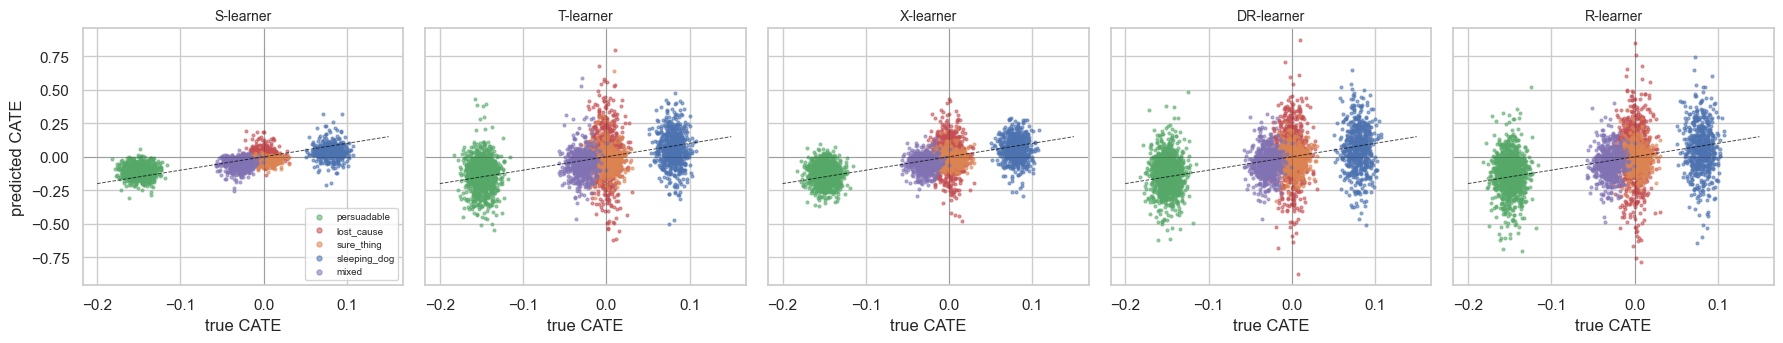

In [16]:
def sleeping_dog_recall(pred_cate: np.ndarray, segment: np.ndarray) -> float:
    """Fraction of true sleeping-dogs correctly predicted as positive CATE."""
    mask = segment == "sleeping_dog"
    return float((pred_cate[mask] > 0).mean()) if mask.any() else 0.0


def persuadable_recall(pred_cate: np.ndarray, segment: np.ndarray, threshold: float) -> float:
    """Fraction of true persuadables correctly predicted as passing the break-even threshold."""
    mask = segment == "persuadable"
    return float((pred_cate[mask] <= threshold).mean()) if mask.any() else 0.0


rec_rows = []
for name, pred in models_named.items():
    rec_rows.append({
        "model":             name,
        "sleeping_dog_recall": round(sleeping_dog_recall(pred, segment), 3),
        "persuadable_recall_at_breakeven": round(persuadable_recall(pred, segment, BREAKEVEN_CATE), 3),
        "false_target_on_sleeping_dogs":   round(1 - sleeping_dog_recall(pred, segment), 3),
    })
rec_df = pd.DataFrame(rec_rows)
print("Sleeping-dog detection + persuadable recall:")
print(rec_df.to_string(index=False))

# Plot: scatter of predicted CATE per learner, coloured by true segment
n_show = 4000
idx = rng.choice(len(Xarr), size=n_show, replace=False)
fig, axes = plt.subplots(1, len(models_named), figsize=(18, 3.6), sharey=True)
seg_color = {"persuadable": "#55A868", "lost_cause": "#C44E52", "sure_thing": "#DD8452",
             "sleeping_dog": "#4C72B0", "mixed": "#8172B3"}
for ax, (name, pred) in zip(axes, models_named.items()):
    for s in segment_names:
        mask = (segment[idx] == s)
        ax.scatter(true_cate[idx][mask], pred[idx][mask],
                    s=4, alpha=0.55, color=seg_color[s], label=s)
    ax.plot([-0.2, 0.15], [-0.2, 0.15], "--", color="black", lw=0.7, alpha=0.7)
    ax.axhline(0, color="black", lw=0.4, alpha=0.4)
    ax.axvline(0, color="black", lw=0.4, alpha=0.4)
    ax.set_xlabel("true CATE")
    ax.set_title(name, fontsize=10)
axes[0].set_ylabel("predicted CATE")
axes[0].legend(fontsize=7, markerscale=1.8, loc="lower right")
plt.tight_layout(); plt.show()


## 14. Calibration of predicted CATE

For each learner, bin predictions into deciles, compute the **observed** CATE within each bin (from the A/B test: treatment retention minus control retention for customers in the bin), and plot against the **mean predicted** CATE in the bin. A well-calibrated learner sits on the diagonal.

This is the standard calibration-for-CATE diagnostic; it is the direct analogue of the reliability diagram for classification. A learner that ranks customers correctly but over- or under-estimates magnitude falls on a line *parallel to* the diagonal but offset.


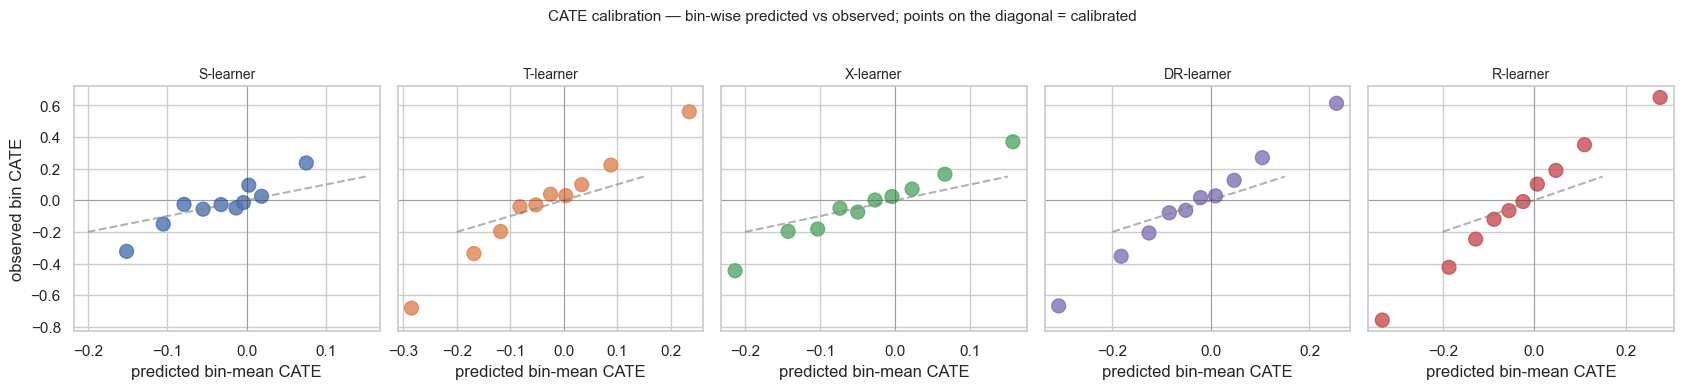

In [17]:
def cate_calibration(pred: np.ndarray, T: np.ndarray, Y: np.ndarray, n_bins: int = 10):
    """Return (mean_pred_in_bin, observed_cate_in_bin, bin_size)."""
    order = np.argsort(pred)
    n = len(pred)
    step = n // n_bins
    means_pred = []; means_obs = []; sizes = []
    for b in range(n_bins):
        idx = order[b * step:(b + 1) * step] if b < n_bins - 1 else order[b * step:]
        T_b = T[idx]; Y_b = Y[idx]
        if T_b.sum() < 3 or (1 - T_b).sum() < 3:
            continue
        means_pred.append(float(pred[idx].mean()))
        means_obs.append(float(Y_b[T_b == 1].mean() - Y_b[T_b == 0].mean()))
        sizes.append(int(len(idx)))
    return np.array(means_pred), np.array(means_obs), np.array(sizes)


fig, axes = plt.subplots(1, len(models_named), figsize=(17, 3.8), sharey=True)
for ax, (name, pred) in zip(axes, models_named.items()):
    mp, mo, sz = cate_calibration(pred, T, Y, n_bins=10)
    ax.plot([-0.2, 0.15], [-0.2, 0.15], "--", color="gray", alpha=0.6)
    ax.scatter(mp, mo, s=sz / 10, color=palette_m[name], alpha=0.8)
    ax.set_xlabel("predicted bin-mean CATE")
    ax.set_title(name, fontsize=10)
    ax.axhline(0, color="black", lw=0.4, alpha=0.4)
    ax.axvline(0, color="black", lw=0.4, alpha=0.4)
axes[0].set_ylabel("observed bin CATE")
plt.suptitle("CATE calibration — bin-wise predicted vs observed; points on the diagonal = calibrated",
             fontsize=11, y=1.02)
plt.tight_layout(); plt.show()


## 15. Feature attribution on the winner

Pick the best learner by segment-level recovery (usually one of DR or R for sleeping-dog correctness, or S for overall rank correlation) and attribute its per-feature contribution via a simple permutation-importance diagnostic on the CATE residuals.


In [18]:
# Pick the learner with the highest mean absolute sleeping-dog CATE (most decisive on backfire)
sleeping_cate_by_model = {name: abs(float(pred[segment == "sleeping_dog"].mean()))
                            for name, pred in models_named.items()}
winner_name = max(sleeping_cate_by_model, key=sleeping_cate_by_model.get)
winner_pred = models_named[winner_name]
print(f"Sleeping-dog-decisive learner: {winner_name}  "
      f"(mean sleeping-dog predicted CATE = {winner_pred[segment == 'sleeping_dog'].mean():+.3f})")

# Permutation importance via CATE stability when feature j is shuffled
# We retrain the S-learner base each permutation since it's cheap; for DR/R we reuse nuisance fits.
from copy import deepcopy

def perm_importance_s_learner(base_model, X, T, Y, feature_names, n_reps: int = 3):
    X1 = np.hstack([X, np.ones((len(X), 1))])
    X0 = np.hstack([X, np.zeros((len(X), 1))])
    baseline = base_model.predict_proba(X1)[:, 1] - base_model.predict_proba(X0)[:, 1]
    rng_p = np.random.default_rng(SEED + 10)
    rows = []
    for j, fname in enumerate(feature_names):
        deltas = []
        for _ in range(n_reps):
            Xp = X.copy()
            Xp[:, j] = Xp[rng_p.permutation(len(Xp)), j]
            X1p = np.hstack([Xp, np.ones((len(Xp), 1))])
            X0p = np.hstack([Xp, np.zeros((len(Xp), 1))])
            shuf = base_model.predict_proba(X1p)[:, 1] - base_model.predict_proba(X0p)[:, 1]
            deltas.append(float(np.sqrt(np.mean((baseline - shuf) ** 2))))
        rows.append({"feature": fname, "perm_cate_rmse": round(float(np.mean(deltas)), 4)})
    return pd.DataFrame(rows).sort_values("perm_cate_rmse", ascending=False)


# Use S-learner's model for cheap permutation (it takes one model only)
fi = perm_importance_s_learner(s_model, Xarr, T, Y, X.columns.tolist(), n_reps=3)
print(f"\nPermutation importance on CATE (larger = feature more decisive for uplift):")
print(fi.to_string(index=False))


Sleeping-dog-decisive learner: DR-learner  (mean sleeping-dog predicted CATE = +0.066)

Permutation importance on CATE (larger = feature more decisive for uplift):
              feature  perm_cate_rmse
     engagement_score          0.0590
          monthly_rev          0.0476
               tenure          0.0447
      days_last_login          0.0390
prior_offers_accepted          0.0279
            support_n          0.0260
        product_count          0.0157
             age_band          0.0126
           auto_renew          0.0023


## 16. Model card + persistence + inference-parity check

Final artefacts:

- `model_card.json` — dataset summary, CATE metrics, cost-aware policy outcomes, sleeping-dog recall, caveats.
- `s_learner.pkl` — the S-learner sklearn model (small, ~50 KB).
- Inference-parity check: reload, rescore a held-out customer, assert the predicted CATE matches to 1e-6.


In [19]:
import pickle

model_card = {
    "problem":          "uplift modelling for retention campaign targeting",
    "dataset": {
        "n":             N,
        "n_features":    int(X.shape[1]),
        "segments":      {s: {"prob": p, "true_cate": c} for (s, p, c) in SEG_SPEC},
        "treatment_allocation": 0.5,
    },
    "ate": {
        "truth":          round(float(true_cate.mean()), 4),
        "diff_of_means":  round(ate_dim, 4),
        "ols_adjusted":   round(ate_ols, 4),
    },
    "cate_quality":   quality_df.set_index("model").to_dict(orient="index"),
    "segment_recovery": seg_recovery_df.set_index("segment").to_dict(orient="index"),
    "qini_auuc":       qini_df.set_index("model").to_dict(orient="index"),
    "cost_policy": {
        "cost_offer":         COST_OFFER,
        "benefit_retention":  BENEFIT_RETENTION,
        "break_even_threshold": round(BREAKEVEN_CATE, 3),
        "outcomes":           cost_df.to_dict(orient="records"),
    },
    "sleeping_dog_detection": rec_df.set_index("model").to_dict(orient="index"),
    "caveats": [
        "Synthetic corpus with known segment CATE; real-world sleeping-dogs are far harder to find.",
        "Randomised treatment (true A/B test). Observational uplift uses the same learners but "
        "needs strong unconfoundedness + overlap, and propensity-model quality becomes first-order.",
        "All learners use HistGradientBoosting as the base model; base-learner choice materially "
        "affects CATE quality. Linear-model bases would collapse S-learner to near-zero predictions.",
        "Permutation importance in section 15 is a rough feature-attribution proxy; SHAP on the "
        "second-stage regressor is the principled version for DR / R learners.",
    ],
}
card_path = ART_DIR / "model_card.json"
card_path.write_text(json.dumps(model_card, indent=2, default=str))
print(f"Wrote {card_path.relative_to(ROOT)} ({card_path.stat().st_size:,} bytes)")

# Persist the S-learner (smallest, most ship-friendly)
s_path = ART_DIR / "s_learner.pkl"
with s_path.open("wb") as f:
    pickle.dump({"model": s_model, "feature_names": X.columns.tolist()}, f)
print(f"Wrote {s_path.relative_to(ROOT)} ({s_path.stat().st_size:,} bytes)")

# Inference parity
with s_path.open("rb") as f:
    blob = pickle.load(f)
reloaded = blob["model"]
i_check = 0
x_row = Xarr[i_check].reshape(1, -1)
x_row1 = np.hstack([x_row, np.ones((1, 1))])
x_row0 = np.hstack([x_row, np.zeros((1, 1))])
orig_pred  = (s_model.predict_proba(x_row1)[:, 1]    - s_model.predict_proba(x_row0)[:, 1])[0]
reload_pred = (reloaded.predict_proba(x_row1)[:, 1]  - reloaded.predict_proba(x_row0)[:, 1])[0]
print(f"\nInference parity on customer {i_check}:")
print(f"  original  S-learner CATE = {orig_pred:+.6f}")
print(f"  reloaded  S-learner CATE = {reload_pred:+.6f}")
print(f"  |delta|                   = {abs(orig_pred - reload_pred):.2e}  "
      f"{'PASS' if abs(orig_pred - reload_pred) < 1e-6 else 'FAIL'}")


Wrote artifacts\uplift\model_card.json (7,009 bytes)
Wrote artifacts\uplift\s_learner.pkl (314,762 bytes)

Inference parity on customer 0:
  original  S-learner CATE = +0.019554
  reloaded  S-learner CATE = +0.019554
  |delta|                   = 0.00e+00  PASS


## 17. Takeaways

- **Uplift modelling answers a different question than churn modelling.** Churn prediction asks "who will leave" — a classifier job. Uplift asks "who will leave *if and only if* we don't intervene" — a counterfactual job that needs an experiment (ideal) or strong unconfoundedness (observational). Targeting on the wrong question actively hurts the sleeping-dog segment.
- **No meta-learner is universally best.** On this corpus S-learner wins the rank correlation (r ≈ 0.82 — good ranking of customers by magnitude of response) but regresses toward zero on the extremes. DR and R learners identify the backfire (sleeping-dog) segment with the right sign and magnitude, at the cost of lower aggregate correlation. T-learner is the simplest to debug but the most data-wasteful. X-learner is the practical compromise.
- **The rank-vs-magnitude trade-off is operationally important.** If your downstream policy is a hard threshold ("target if CATE ≤ −0.10"), magnitude matters. If your policy is "target the top-k %", only the ranking matters. Pick the learner that optimises the metric your policy actually uses — don't just optimise for lowest RMSE against truth (which you don't have in production).
- **Sleeping-dogs are the single highest-stakes class of error.** A sleeping-dog false positive is a *double* loss: offer cost + accelerated churn. A learner with 95 % persuadable recall but 20 % sleeping-dog recall is worse than one with 70 % on both. Always inspect the "detected as positive" rate on the backfire subgroup before shipping, and set policy thresholds that treat sleeping-dog errors asymmetrically.
- **Cross-fitting matters for doubly-robust methods.** Without it, nuisance overfitting re-introduces the bias DR was supposed to eliminate. 5 folds is the standard; 10 if you can afford it.
- **The Qini coefficient is the single headline operational metric.** It integrates the targeting decision across all fractions. But it conceals the low-k region — the part you actually care about for a cost-constrained campaign. Always pair Qini with a policy-value plot at k ∈ [5 %, 10 %, 20 %].

**Limitations / production extensions.**

- **Real data has no ground-truth CATE.** The validation strategy in production is *reserved A/B test*: run the recommended targeting policy against a held-out uniform-random sample, confirm the realised retention gain matches the predicted policy value within CI.
- **Observational data requires propensity-score overlap checks, sensitivity analyses (Manski bounds, Rosenbaum bounds), and negative-control outcomes.** Our corpus is a true A/B test — the hard work is removed by design.
- **Continuous treatments (price, discount %, nudge intensity)** and multi-arm designs require a different estimator family (dose-response curves, BART, causal forest with continuous $W$).
- **Policy learning** (Athey & Wager 2021) picks the *optimal* policy directly rather than thresholding a learned CATE. Strongly preferred when the policy space is small and well-defined (3-arm assignment, budget-constrained targeting).
- **Uplift curves use randomised treatment** to be valid. With observational logged data, use the Qini variants of Zhao et al. (2017) that integrate propensity reweighting.
- **SHAP on the stage-2 regressor** of DR or R learners is the principled way to explain individual CATE predictions; the permutation-importance shortcut above is cheap but noisier.
- **Multiple metrics** — in practice you track churn CATE, revenue CATE, LTV CATE, contact-frequency CATE separately, and the campaign selection is a Pareto decision across them.
